In [1]:
# @title
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [2]:
# @title
import json
import torch
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from huggingface_hub import login
from unsloth import is_bf16_supported
from google.colab import drive, userdata
from datasets import load_dataset,Dataset
from unsloth import FastSentenceTransformer
from IPython.display import Markdown, display
from transformers.trainer_utils import get_last_checkpoint
from transformers.generation.streamers import BaseStreamer
from sentence_transformers.training_args import BatchSamplers
from sentence_transformers.evaluation import InformationRetrievalEvaluator

from sentence_transformers import (
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
    losses
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


/tmp/ipykernel_4294/2568590586.py:15: DeprecationWarning: Importing from 'sentence_transformers.training_args' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.training_args' instead.
  from sentence_transformers.training_args import BatchSamplers
/tmp/ipykernel_4294/2568590586.py:16: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import InformationRetrievalEvaluator
/tmp/ipykernel_4294/2568590586.py:18: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import (


In [3]:
# @title
!rm -rf /root/.cache/huggingface

!rm -rf /root/.cache/pip
!rm -rf /tmp/*

!du -sh /root/.cache/* /tmp/* /content/* 2>/dev/null | sort -hr | head -20

56M	/root/.cache/node-gyp
55M	/content/sample_data
2.0M	/content/unsloth_compiled_cache
32K	/root/.cache/matplotlib
8.0K	/root/.cache/antigravity


In [4]:
MODEL_NAME="unsloth/embeddinggemma-300m"
MAX_LENGTH=1024
RANK=8
MAX_STEPS=30
NUM_TRAIN_EPOCHS=1
LEARNING_RATE=2e-5

In [6]:
# @title
drive.mount('/content/drive')

FT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/fine-tuning")
OUTPUT_DIR = FT_DIR / "embedding" / "outputs" / f'{RANK}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOG_DIR = OUTPUT_DIR / "logs"
PLOT_DIR = OUTPUT_DIR / "plots"
ADAPTER_PATH = OUTPUT_DIR / "embeddinggemma-medical-qa"

training_plots_img = PLOT_DIR / "training_plots.png"
training_log_dir = LOG_DIR / "training_log.json"
gpu_stats_file = LOG_DIR / "gpu_stats.json"

HF_HUB_DIR = "eneotu/embeddinggemma-medical-qa"

login(token=userdata.get('HF_TOKEN'))
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

Mounted at /content/drive


In [7]:
model = FastSentenceTransformer.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_LENGTH,
    full_finetuning = False,
)


model = FastSentenceTransformer.get_peft_model(
    model,
    r = RANK,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 2 * RANK,
    lora_dropout = 0,
    bias = "none",

    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
    task_type = "FEATURE_EXTRACTION"
)

Unsloth: Not planning a device map; SentenceTransformer moves the assembled model onto a single device. Using `sequential`.
==((====))==  Unsloth 2026.9.7: Fast Gemma3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


In [8]:
stream_train = list(load_dataset("tomaarsen/miriad-4.4M-split", split = "train",streaming = True).take(10000))
stream_eval = list(load_dataset("tomaarsen/miriad-4.4M-split", split = "eval",streaming = True).take(2000))

train_dataset = Dataset.from_generator(lambda: (yield from stream_train))
eval_dataset = Dataset.from_generator(lambda: (yield from stream_eval))

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [9]:
queries = dict(enumerate(eval_dataset["question"]))
corpus = dict(enumerate(list(eval_dataset["passage_text"]) + train_dataset["passage_text"][:2000]))
relevant_docs = {idx: [idx] for idx in queries}
evaluator = InformationRetrievalEvaluator(
    queries = queries,
    corpus = corpus,
    relevant_docs = relevant_docs,
    show_progress_bar = False,
    batch_size = 64,
)
with torch.autocast(device_type = "cuda", dtype = model.dtype, enabled = model.dtype != torch.float16):
    print(evaluator(model))

/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:2825: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:2825: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:2825: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:2825: UserWarning: 'has_mkldnn' is deprecated, please use 'torch.backends.mkldnn.is_available()'
  return original(name)


{'cosine_accuracy@1': 0.046, 'cosine_accuracy@3': 0.5565, 'cosine_accuracy@5': 0.645, 'cosine_accuracy@10': 0.741, 'cosine_precision@1': 0.046, 'cosine_precision@3': 0.1855, 'cosine_precision@5': 0.129, 'cosine_precision@10': 0.0741, 'cosine_recall@1': 0.046, 'cosine_recall@3': 0.5565, 'cosine_recall@5': 0.645, 'cosine_recall@10': 0.741, 'cosine_ndcg@10': 0.42032660859406795, 'cosine_mrr@10': 0.31481408730158744, 'cosine_map@100': 0.3224279897433471}


In [10]:
# @title ### Training

loss = losses.MultipleNegativesRankingLoss(model)

trainer = SentenceTransformerTrainer(
    model = model,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,
    loss = loss,
    args = SentenceTransformerTrainingArguments(
        max_steps = MAX_STEPS,
        learning_rate = LEARNING_RATE,
        # num_train_epochs = NUM_TRAIN_EPOCHS,

        per_device_train_batch_size = 64,
        per_device_eval_batch_size = 64,
        gradient_accumulation_steps = 2,
        logging_steps = 5,
        warmup_ratio = 0.03,
        prompts = {
          "question": model.prompts["query"],
          "passage_text": model.prompts["document"],
        },

        output_dir = OUTPUT_DIR,
        report_to = "none",

        eval_strategy = "steps",
        eval_steps = 5,
        bf16 = is_bf16_supported(),
        lr_scheduler_type = "linear",
        batch_sampler = BatchSamplers.NO_DUPLICATES,
    ),
    evaluator = evaluator,
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

In [11]:
# @title
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)

gpu_info = {
  "gpu_name": gpu_stats.name,
  "max_memory": max_memory,
  "start_reserved_memory_gb": start_gpu_memory,
}

print(f"GPU: {gpu_info['gpu_name']}")
print(f"Maximum memory: {gpu_info['max_memory']}")
print(f"Reserved memory: {gpu_info['start_reserved_memory_gb']} GB")

GPU: Tesla T4
Maximum memory: 14.563
Reserved memory: 4.492 GB


In [12]:
last_checkpoint = get_last_checkpoint(OUTPUT_DIR)

if last_checkpoint is not None:
  print(f"Resuming training from checkpoint: {last_checkpoint}")
else:
  print("No checkpoint found. Starting fresh training...")

trainer_stats = trainer.train(resume_from_checkpoint=last_checkpoint)

No checkpoint found. Starting fresh training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,000 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 64 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (64 x 2 x 1) = 128
 "-____-"     Trainable parameters = 6,807,552 of 309,670,656 (2.20% trained)


Step,Training Loss,Validation Loss,Cosine Accuracy@1,Cosine Accuracy@3,Cosine Accuracy@5,Cosine Accuracy@10,Cosine Precision@1,Cosine Precision@3,Cosine Precision@5,Cosine Precision@10,Cosine Recall@1,Cosine Recall@3,Cosine Recall@5,Cosine Recall@10,Cosine Ndcg@10,Cosine Mrr@10,Cosine Map@100
5,1.271400,0.923340,0.421000,0.699500,0.771000,0.833500,0.421000,0.233167,0.154200,0.083350,0.421000,0.699500,0.771000,0.833500,0.637489,0.573508,0.579494
10,0.819200,0.546387,0.606500,0.768000,0.826000,0.876000,0.606500,0.256000,0.165200,0.087600,0.606500,0.768000,0.826000,0.876000,0.742182,0.699166,0.703674
15,0.438200,0.400146,0.664500,0.805500,0.853500,0.897000,0.664500,0.268500,0.170700,0.089700,0.664500,0.805500,0.853500,0.897000,0.782064,0.745055,0.748541
20,0.366800,0.333740,0.688000,0.819000,0.866500,0.903500,0.688000,0.273000,0.173300,0.090350,0.688000,0.819000,0.866500,0.903500,0.797069,0.762731,0.766217
25,0.313900,0.299805,0.700000,0.827500,0.871500,0.909500,0.700000,0.275833,0.174300,0.090950,0.700000,0.827500,0.871500,0.909500,0.805385,0.771876,0.775263
30,0.316700,0.286621,0.703000,0.830500,0.873000,0.912500,0.703000,0.276833,0.174600,0.091250,0.703000,0.830500,0.873000,0.912500,0.808244,0.774715,0.777954


In [13]:
# @title
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)


gpu_info.update({
  "trainer_stats": trainer_stats.metrics['train_runtime'],
  "trainer_stats_min": round(trainer_stats.metrics['train_runtime']/60, 2),
  "used_memory": used_memory,
  "used_memory_for_lora": used_memory_for_lora,
  "used_percentage": used_percentage,
  "lora_percentage": lora_percentage,
})

with open(gpu_stats_file, "w") as f:
  json.dump(gpu_info, f, indent=2)

print(f"GPU stats saved to: {gpu_stats_file}")

print(f"Training time: {gpu_info['trainer_stats_min']} minutes.")
print(f"Peak reserved memory: = {gpu_info['used_memory']} GB.")
print(f"Peak reserved memory for training: = {gpu_info['used_memory_for_lora']} GB.")
print(f"Peak reserved memory % of max memory: = {gpu_info['used_percentage']} %.")
print(f"Peak reserved memory for training % of max memory: = {gpu_info['lora_percentage']} %.")

GPU stats saved to: /content/drive/MyDrive/Colab Notebooks/fine-tuning/embedding/outputs/8/logs/gpu_stats.json
Training time: 46.24 minutes.
Peak reserved memory: = 11.535 GB.
Peak reserved memory for training: = 7.043 GB.
Peak reserved memory % of max memory: = 79.208 %.
Peak reserved memory for training % of max memory: = 48.362 %.


In [14]:
with torch.autocast(device_type = "cuda", dtype = model.dtype, enabled = model.dtype != torch.float16):
    print(evaluator(model))

{'cosine_accuracy@1': 0.703, 'cosine_accuracy@3': 0.8305, 'cosine_accuracy@5': 0.873, 'cosine_accuracy@10': 0.9125, 'cosine_precision@1': 0.703, 'cosine_precision@3': 0.2768333333333333, 'cosine_precision@5': 0.17460000000000003, 'cosine_precision@10': 0.09125000000000001, 'cosine_recall@1': 0.703, 'cosine_recall@3': 0.8305, 'cosine_recall@5': 0.873, 'cosine_recall@10': 0.9125, 'cosine_ndcg@10': 0.8082442348615091, 'cosine_mrr@10': 0.7747152777777774, 'cosine_map@100': 0.7779535102106035}


In [15]:
# @title
log_history = trainer.state.log_history

grad_steps = [entry["step"] for entry in log_history if "grad_norm" in entry]
grad_norms = [entry["grad_norm"] for entry in log_history if "grad_norm" in entry]

train_steps = [entry["step"] for entry in log_history if "loss" in entry]
train_loss = [entry["loss"] for entry in log_history if "loss" in entry]

eval_steps = [entry["step"] for entry in log_history if "eval_loss" in entry]
eval_loss = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]

lr_steps = [entry["step"] for entry in log_history if "learning_rate" in entry]
learning_rates = [entry["learning_rate"] for entry in log_history if "learning_rate" in entry]

log_history_df = pd.DataFrame(log_history)
log_history_df.to_json(training_log_dir, index=False)
log_history_df.head(5)

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_cosine_accuracy@1,eval_cosine_accuracy@3,eval_cosine_accuracy@5,eval_cosine_accuracy@10,...,eval_cosine_mrr@10,eval_cosine_map@100,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.2714,11.317077,0.000018,0.063694,5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,0.063694,5,0.923340,0.4210,0.6995,0.771,0.8335,...,0.573508,0.579494,336.3923,5.945,0.095,NaN,NaN,NaN,NaN,NaN
2,0.8192,7.214070,0.000014,0.127389,10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,0.127389,10,0.546387,0.6065,0.7680,0.826,0.8760,...,0.699166,0.703674,335.8874,5.954,0.095,NaN,NaN,NaN,NaN,NaN
4,0.4382,3.764944,0.000011,0.191083,15,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# @title
def publication_style():
  plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
      "Times New Roman",
      "DejaVu Serif",
      "Computer Modern Roman",
    ],

    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,

    "figure.dpi": 150,
    "savefig.dpi": 600,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "axes.spines.top": False,
    "axes.spines.right": False,
  })

def ema(values, alpha=0.15):
  smoothed = [values[0]]
  for v in values[1:]:
    smoothed.append(alpha * v + (1 - alpha) * smoothed[-1])
  return smoothed

publication_style()

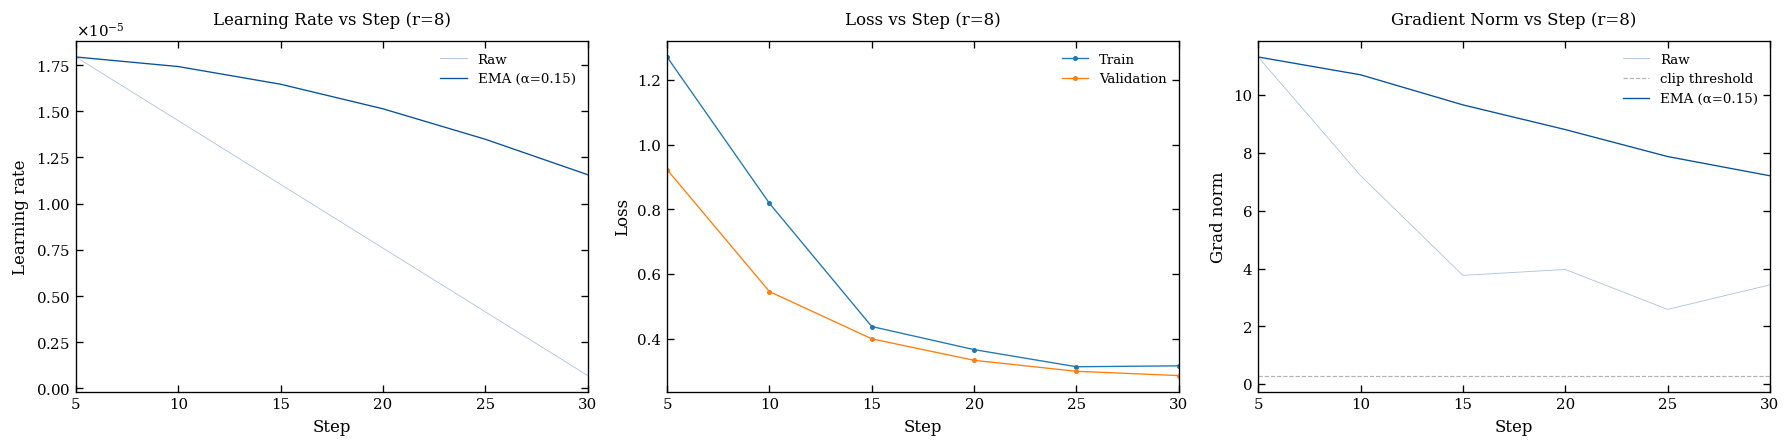

In [26]:
# @title ### Train and validation losses

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), dpi=120)

for ax in axes:
  ax.spines['top'].set_visible(True)
  ax.spines['right'].set_visible(True)
  ax.tick_params(top=True, right=True, direction='in')

ax = axes[0]
ax.plot(lr_steps, learning_rates, color="#08519c", linewidth=0.5, alpha=0.35, label="Raw")
ax.plot(lr_steps, ema(learning_rates), color="#08519c", linewidth=0.8, label="EMA (α=0.15)")

ax.set_xlabel("Step")
ax.set_ylabel("Learning rate")
ax.set_title(f"Learning Rate vs Step (r={RANK})", pad=10)

ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
ax.set_xlim(min(lr_steps), max(lr_steps))
ax.margins(x=0.01)
ax.legend(frameon=False, loc="upper right")

ax = axes[1]
ax.plot(train_steps, train_loss, linewidth=0.8, label="Train", marker='o', markersize=2,)
ax.plot(eval_steps, eval_loss, linewidth=0.8, label="Validation", marker='o', markersize=2,)

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title(f"Loss vs Step (r={RANK})", pad=10)
all_steps = train_steps + eval_steps
ax.set_xlim(min(all_steps), max(all_steps))
ax.margins(x=0.01)
ax.legend(frameon=False, loc="upper right")

ax = axes[2]
ax.plot(grad_steps, grad_norms, color="#08519c", linewidth=0.5, alpha=0.35, label="Raw")
ax.axhline(0.3, color="gray", linewidth=0.7, linestyle="--", alpha=0.6, label="clip threshold")
ax.plot(grad_steps, ema(grad_norms), color="#08519c", linewidth=0.8, label="EMA (α=0.15)")

ax.set_xlabel("Step")
ax.set_ylabel("Grad norm")
ax.set_title(f"Gradient Norm vs Step (r={RANK})", pad=10)
ax.set_xlim(min(grad_steps), max(grad_steps))
ax.margins(x=0.01)
ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
fig.savefig(training_plots_img, bbox_inches="tight", dpi=600)
plt.show()

In [18]:
# @title Markdown streamer
class MarkdownStreamer(BaseStreamer):

    def __init__(self, tokenizer, skip_prompt=True):
        self.tokenizer = tokenizer
        self.skip_prompt = skip_prompt
        self.first_call = True
        self.token_cache = []
        self.decoded_text = ""
        self.display_handle = display(Markdown(""), display_id=True)

    def put(self, value):
        if torch.is_tensor(value):
            value = value.tolist()

        if isinstance(value[0], list):
            value = value[0]

        if self.first_call and self.skip_prompt:
            self.first_call = False
            return

        self.token_cache.extend(value)

        text = self.tokenizer.decode(self.token_cache, skip_special_tokens=True)
        self.decoded_text = text
        self.display_handle.update(Markdown(self.decoded_text))

    def end(self):
        self.display_handle.update(Markdown(self.decoded_text))

In [19]:
# @title ### Inference

query = "Patient presents with sharp chest pain that improves when leaning forward."

candidates = [
    "Acute Pericarditis often involves pleuritic chest pain relieved by sitting up and leaning forward.",
    "Myocardial Infarction typically presents with crushing substernal pressure and radiation to the left arm.",
    "Pneumothorax is characterized by sudden onset shortness of breath and unilateral chest pain.",
    "Gastroesophageal Reflux Disease (GERD) causes burning retrosternal pain usually after meals."
]

query_emb = model.encode(query, convert_to_tensor = True)
candidate_embs = model.encode(candidates, convert_to_tensor = True)
similarities = model.similarity(query_emb, candidate_embs)

ranking = similarities.argsort(descending = True)[0]

for idx in ranking.tolist():
    score = similarities[0][idx].item()
    text = candidates[idx]
    print(f"{score:.4f} | {text}")

0.7397 | Acute Pericarditis often involves pleuritic chest pain relieved by sitting up and leaning forward.
0.5801 | Pneumothorax is characterized by sudden onset shortness of breath and unilateral chest pain.
0.5610 | Myocardial Infarction typically presents with crushing substernal pressure and radiation to the left arm.
0.4368 | Gastroesophageal Reflux Disease (GERD) causes burning retrosternal pain usually after meals.


In [24]:
# @title # Save fine-tuned model
model.save_pretrained(ADAPTER_PATH)
model.tokenizer.save_pretrained(ADAPTER_PATH)

# model.push_to_hub(HF_HUB_DIR, token=userdata.get('HF_TOKEN'))
# model.tokenizer.push_to_hub(HF_HUB_DIR, token=userdata.get('HF_TOKEN'))

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpl0ntw_qg/tokenizer.json:  71%|#######   | 23.6MB / 33.4MB            

  ...pl0ntw_qg/tokenizer.model: 100%|##########| 4.69MB / 4.69MB            

  ...2_Dense/model.safetensors:   3%|2         |  141kB / 4.72MB            

...

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpho36tyk4/tokenizer.json:  96%|#########5| 31.9MB / 33.4MB            

  ...pho36tyk4/tokenizer.model: 100%|##########| 4.69MB / 4.69MB            